In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler


# Prediction of the survival of the Titanic

In [2]:
print('train data info:')

data1=pd.read_csv('./train.csv')
df1=data1.copy()

print(df1.info(),'\n\n')
print(df1.describe(),'\n\n')


print('test data info:')

data2=pd.read_csv('./test.csv')
df2=data2.copy()

print(df2.info(),'\n\n')
print(df2.describe())

train data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None 


       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     2

### preparing train & test inputs

In [3]:
# I drop PassengerId and Ticket and Name and Cabin columns because they are unique for each person and doesn't affect whether the person survives or not

# train data
df1.drop('PassengerId',axis=1,inplace=True)
df1.drop('Ticket',axis=1,inplace=True)
df1.drop('Name',axis=1,inplace=True)
#df1.drop('Cabin',axis=1,inplace=True)

#test data
df2.drop('PassengerId',axis=1,inplace=True)
df2.drop('Ticket',axis=1,inplace=True)
df2.drop('Name',axis=1,inplace=True)
#df2.drop('Cabin',axis=1,inplace=True)


In [4]:
print('train data information:')
print(df1.info())

print('\n\ntest data information:')
print(df2.info())

train data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB
None


test data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch  

In [5]:
# drop Survived column from train data

train_input=df1.loc[:,'Pclass':'Embarked']
train_input.info()

test_input=df2
test_input.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Cabin     204 non-null    object 
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 55.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       332 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Cabin     91 non-null 

### preparing train outputs

In [6]:
train_output=df1.loc[:,'Survived']

train_output.info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Survived
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


### converting categorical features to label-encoding format


In [7]:
# I use label-encoding to convert categorical features to numerical features because if we use one-hot vector format, the dimensions of train and test data will be different

train_input['Sex']=pd.factorize(train_input['Sex'])[0]
train_input['Cabin']=pd.factorize(train_input['Cabin'])[0]
train_input['Embarked']=pd.factorize(train_input['Embarked'])[0]

print('\ntrain_input after convering categorical features to numbers:\n\n',train_input)



test_input['Sex']=pd.factorize(test_input['Sex'])[0]
test_input['Cabin']=pd.factorize(test_input['Cabin'])[0]
test_input['Embarked']=pd.factorize(test_input['Embarked'])[0]

print('\ntest_input after convering categorical features to numbers:\n\n',test_input)


train_input after convering categorical features to numbers:

      Pclass  Sex   Age  SibSp  Parch     Fare  Cabin  Embarked
0         3    0  22.0      1      0   7.2500     -1         0
1         1    1  38.0      1      0  71.2833      0         1
2         3    1  26.0      0      0   7.9250     -1         0
3         1    1  35.0      1      0  53.1000      1         0
4         3    0  35.0      0      0   8.0500     -1         0
..      ...  ...   ...    ...    ...      ...    ...       ...
886       2    0  27.0      0      0  13.0000     -1         0
887       1    1  19.0      0      0  30.0000    145         0
888       3    1   NaN      1      2  23.4500     -1         0
889       1    0  26.0      0      0  30.0000    146         1
890       3    0  32.0      0      0   7.7500     -1         2

[891 rows x 8 columns]

test_input after convering categorical features to numbers:

      Pclass  Sex   Age  SibSp  Parch      Fare  Cabin  Embarked
0         3    0  34.5      0

### fill unknown cells

In [8]:
# we can fill in the unknown fields of a data with the values of the corresponding fields in the most similar or closest data in terms of vector distance to the desired data. for this I use KNNImputer.

imputer=KNNImputer(n_neighbors=5)
train_input=pd.DataFrame(imputer.fit_transform(train_input),columns=train_input.columns)
print('train data:')
print(train_input.info())


test_input=pd.DataFrame(imputer.fit_transform(test_input),columns=test_input.columns)
print('\n\ntest data:')
print(test_input.info())

train data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    float64
 1   Sex       891 non-null    float64
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    float64
 4   Parch     891 non-null    float64
 5   Fare      891 non-null    float64
 6   Cabin     891 non-null    float64
 7   Embarked  891 non-null    float64
dtypes: float64(8)
memory usage: 55.8 KB
None


test data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    float64
 1   Sex       418 non-null    float64
 2   Age       418 non-null    float64
 3   SibSp     418 non-null    float64
 4   Parch     418 non-null    float64
 5   Fare      418 non-null    float64
 6   Cabin     418 

### normalizing numerical features (for better optimization)

In [9]:
scaler=StandardScaler()

train_input[train_input.select_dtypes(include=['float64']).columns]=scaler.fit_transform(train_input.select_dtypes(include=['float64']))
print('train data:')
print(train_input.head())


test_input[test_input.select_dtypes(include=['float64']).columns]=scaler.fit_transform(test_input.select_dtypes(include=['float64']))
print('\n\ntest data:')
print(test_input.head())

train data:
     Pclass       Sex       Age     SibSp     Parch      Fare     Cabin  \
0  0.827377 -0.737695 -0.575913  0.432793 -0.473674 -0.502445 -0.443934   
1 -1.566107  1.355574  0.620431  0.432793 -0.473674  0.786845 -0.415344   
2  0.827377  1.355574 -0.276827 -0.474545 -0.473674 -0.488854 -0.443934   
3 -1.566107  1.355574  0.396117  0.432793 -0.473674  0.420730 -0.386754   
4  0.827377 -0.737695  0.396117 -0.474545 -0.473674 -0.486337 -0.443934   

   Embarked  
0 -0.562619  
1  1.003923  
2 -0.562619  
3 -0.562619  
4 -0.562619  


test data:
     Pclass       Sex       Age     SibSp     Parch      Fare     Cabin  \
0  0.873482 -0.755929  0.338467 -0.499470 -0.400248 -0.497066 -0.434098   
1  0.873482  1.322876  1.304379  0.616992 -0.400248 -0.511929 -0.434098   
2 -0.315819 -0.755929  2.463473 -0.499470 -0.400248 -0.463757 -0.434098   
3  0.873482 -0.755929 -0.241081 -0.499470 -0.400248 -0.482130 -0.434098   
4  0.873482  1.322876 -0.627445  0.616992  0.619896 -0.417154 -0.

## neural network implementation

### defining activation functions

In [10]:
def relu(z):
    return np.maximum(0,z) 

def sigmoid(z):
    return 1/(1+np.exp(-z))

def reluDerivative(z):
    return (z>0).astype(float)
    
def sigmoidDerivative(z):
    return sigmoid(z)*(1-sigmoid(z))

### defining cost function

In [11]:
def binaryCrossrossEntropy(y,y_pred,n):# n = number of input entries
    #return -(1/n) * np.sum(y*np.log(y_pred) + (pd.Series(np.ones(n))-y)*np.log(pd.Series(np.ones(n))-y_pred) )  
    return -(1/n) * np.sum(y.T@np.log(y_pred) + (1-y).T@np.log(1-y_pred) )  


### defining model

In [12]:
class neuralNetwork:
    def __init__(self,inputsize,hiddensize1,hiddensize2,outputsize):
        self.w1=np.random.normal(0,1,(inputsize,hiddensize1)) # mean = 0 & std = 1
        self.b1=np.random.normal(0,1,(hiddensize1))
        self.w2=np.random.normal(0,1,(hiddensize1,hiddensize2))
        self.b2=np.random.normal(0,1,(hiddensize2))
        self.w3=np.random.normal(0,1,(hiddensize2,outputsize))
        self.b3=np.random.normal(0,1,(outputsize))

    def forward(self,x):
        self.z1=x@self.w1 + self.b1
        self.a1=relu(self.z1)
        self.z2=self.a1@self.w2 + self.b2
        self.a2=relu(self.z2)
        self.z3=self.a2@self.w3 + self.b3
        self.a3=sigmoid(self.z3)

        return self.a3
    
    def backward(self,x,y,lr): # lr = learning rate
        n=y.shape[0]
        y=y.values.reshape(y.shape[0],1)

        dz3=self.a3-y
        dw3=(1/n) * self.a2.T@(dz3)
        db3=(1/n) * np.sum(dz3,axis=0)

        da2=dz3@(self.w3.T)
        dz2=da2*reluDerivative(self.z2)
        dw2=(1/n) * self.a1.T@(dz2)
        db2=(1/n) * np.sum(dz2,axis=0)

        da1=dz2@(self.w2.T)
        dz1=da1*reluDerivative(self.z1)
        dw1=(1/n) * x.T@(dz1)
        db1=(1/n) * np.sum(dz1,axis=0)

        # gradient descent
        self.w3 -= lr*dw3
        self.b3 -= lr*db3

        self.w2 -= lr*dw2
        self.b2 -= lr*db2

        self.w1 -= lr*dw1
        self.b1 -= lr*db1


    def train(self,x,y,lr,number_of_epochs):
        train_losses=[]
        counter=0
        patience=500 # for early stopping
        best_loss=10000000
        for epoch in range(number_of_epochs):
            y_pred=self.forward(x)

            loss=binaryCrossrossEntropy(y,y_pred,y.shape[0])
            train_losses.append(loss)
            
            if loss < best_loss:
                best_loss=loss
                counter=0
            else:
                counter+=1

            if counter == patience: # early stopping
                return train_losses
            
            self.backward(x,y,lr)

            if epoch % 5 == 0:
                print(f'Epoch {epoch+1}/{number_of_epochs}: train loss = {loss}')

        return train_losses
    
    def predict(self,x):   # predict function uses forward pass function to predict
        return self.forward(x)
    







### model training and evaluation 

Epoch 1/40000: train loss = -0.0
Epoch 6/40000: train loss = 0.608732704757304
Epoch 11/40000: train loss = 0.5595210102658544
Epoch 16/40000: train loss = 0.5330161889601494
Epoch 21/40000: train loss = 0.515048884777118
Epoch 26/40000: train loss = 0.5022222281140226


/home/zahra/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


Epoch 31/40000: train loss = 0.49106557361468
Epoch 36/40000: train loss = 0.4814825516216878
Epoch 41/40000: train loss = 0.4743322888207632
Epoch 46/40000: train loss = 0.4693389936452059
Epoch 51/40000: train loss = 0.46586326711632453
Epoch 56/40000: train loss = 0.4633035377243137
Epoch 61/40000: train loss = 0.4611291642846088
Epoch 66/40000: train loss = 0.4593344027252638
Epoch 71/40000: train loss = 0.4578343612893727
Epoch 76/40000: train loss = 0.4564571621009673
Epoch 81/40000: train loss = 0.45504668579659285
Epoch 86/40000: train loss = 0.4537891167248255
Epoch 91/40000: train loss = 0.4527165058694109
Epoch 96/40000: train loss = 0.4516878940388245
Epoch 101/40000: train loss = 0.4504736003164945
Epoch 106/40000: train loss = 0.4493482779625848
Epoch 111/40000: train loss = 0.44812955621356765
Epoch 116/40000: train loss = 0.4467822004527191
Epoch 121/40000: train loss = 0.44562533223584105
Epoch 126/40000: train loss = 0.44417069951813243
Epoch 131/40000: train loss = 0

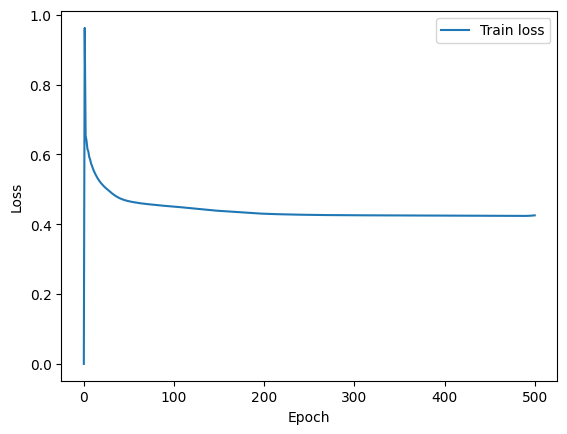

In [13]:
model=neuralNetwork(8,2,2,1)
train_losses=model.train(train_input,train_output,0.4,40000) # lr = 0.01    &   number_of_epochs = 200

plt.plot(train_losses,label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### test samples predictions

In [14]:
test_output=model.predict(test_input)

df=pd.DataFrame(test_output)
df=df.applymap(lambda x:0 if x<0.5 else 1)
df=pd.DataFrame({'PassengerId':data2['PassengerId'],
                'Survived':df.values.reshape(418)})
df.to_csv('test_output.csv',index=False)

/tmp/ipykernel_24998/1279692820.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df=df.applymap(lambda x:0 if x<0.5 else 1)


##### the accuracy of this output on kaggle site was 77.27% and the best accuracy was 77.75% with 3 and 2 neurons for hidden layers